# Reservoir filling data

This notebook explores the weekly reservoir data with clear, meaningful English column names.

In [1]:
# Import packages for the table summaries and plots below.
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Load the source data and replace abbreviated Norwegian headers.
df = pd.read_csv("reservoirs.csv")
df.columns = [
    "Observation Date",
    "Area Type",
    "Area Code",
    "Iso Year",
    "Iso Week",
    "Fill Level",
    "Capacity TWh",
    "Stored Energy TWh",
    "Next Publication Date",
    "Previous Week Fill Level",
    "Weekly Fill Level Change",
]

# The source uses 0001-01-01 as a placeholder for an unavailable publication date.
df["Observation Date"] = pd.to_datetime(
    df["Observation Date"], format="%Y-%m-%d", errors="coerce"
)
df["Next Publication Date"] = pd.to_datetime(
    df["Next Publication Date"], format="ISO8601", errors="coerce"
)

df.head()

,Observation Date,Area Type,Area Code,Iso Year,Iso Week,Fill Level,Capacity TWh,Stored Energy TWh,Next Publication Date,Previous Week Fill Level,Weekly Fill Level Change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,NaT,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,NaT,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,NaT,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,NaT,0.311122,-0.010301


## Distributions for every column

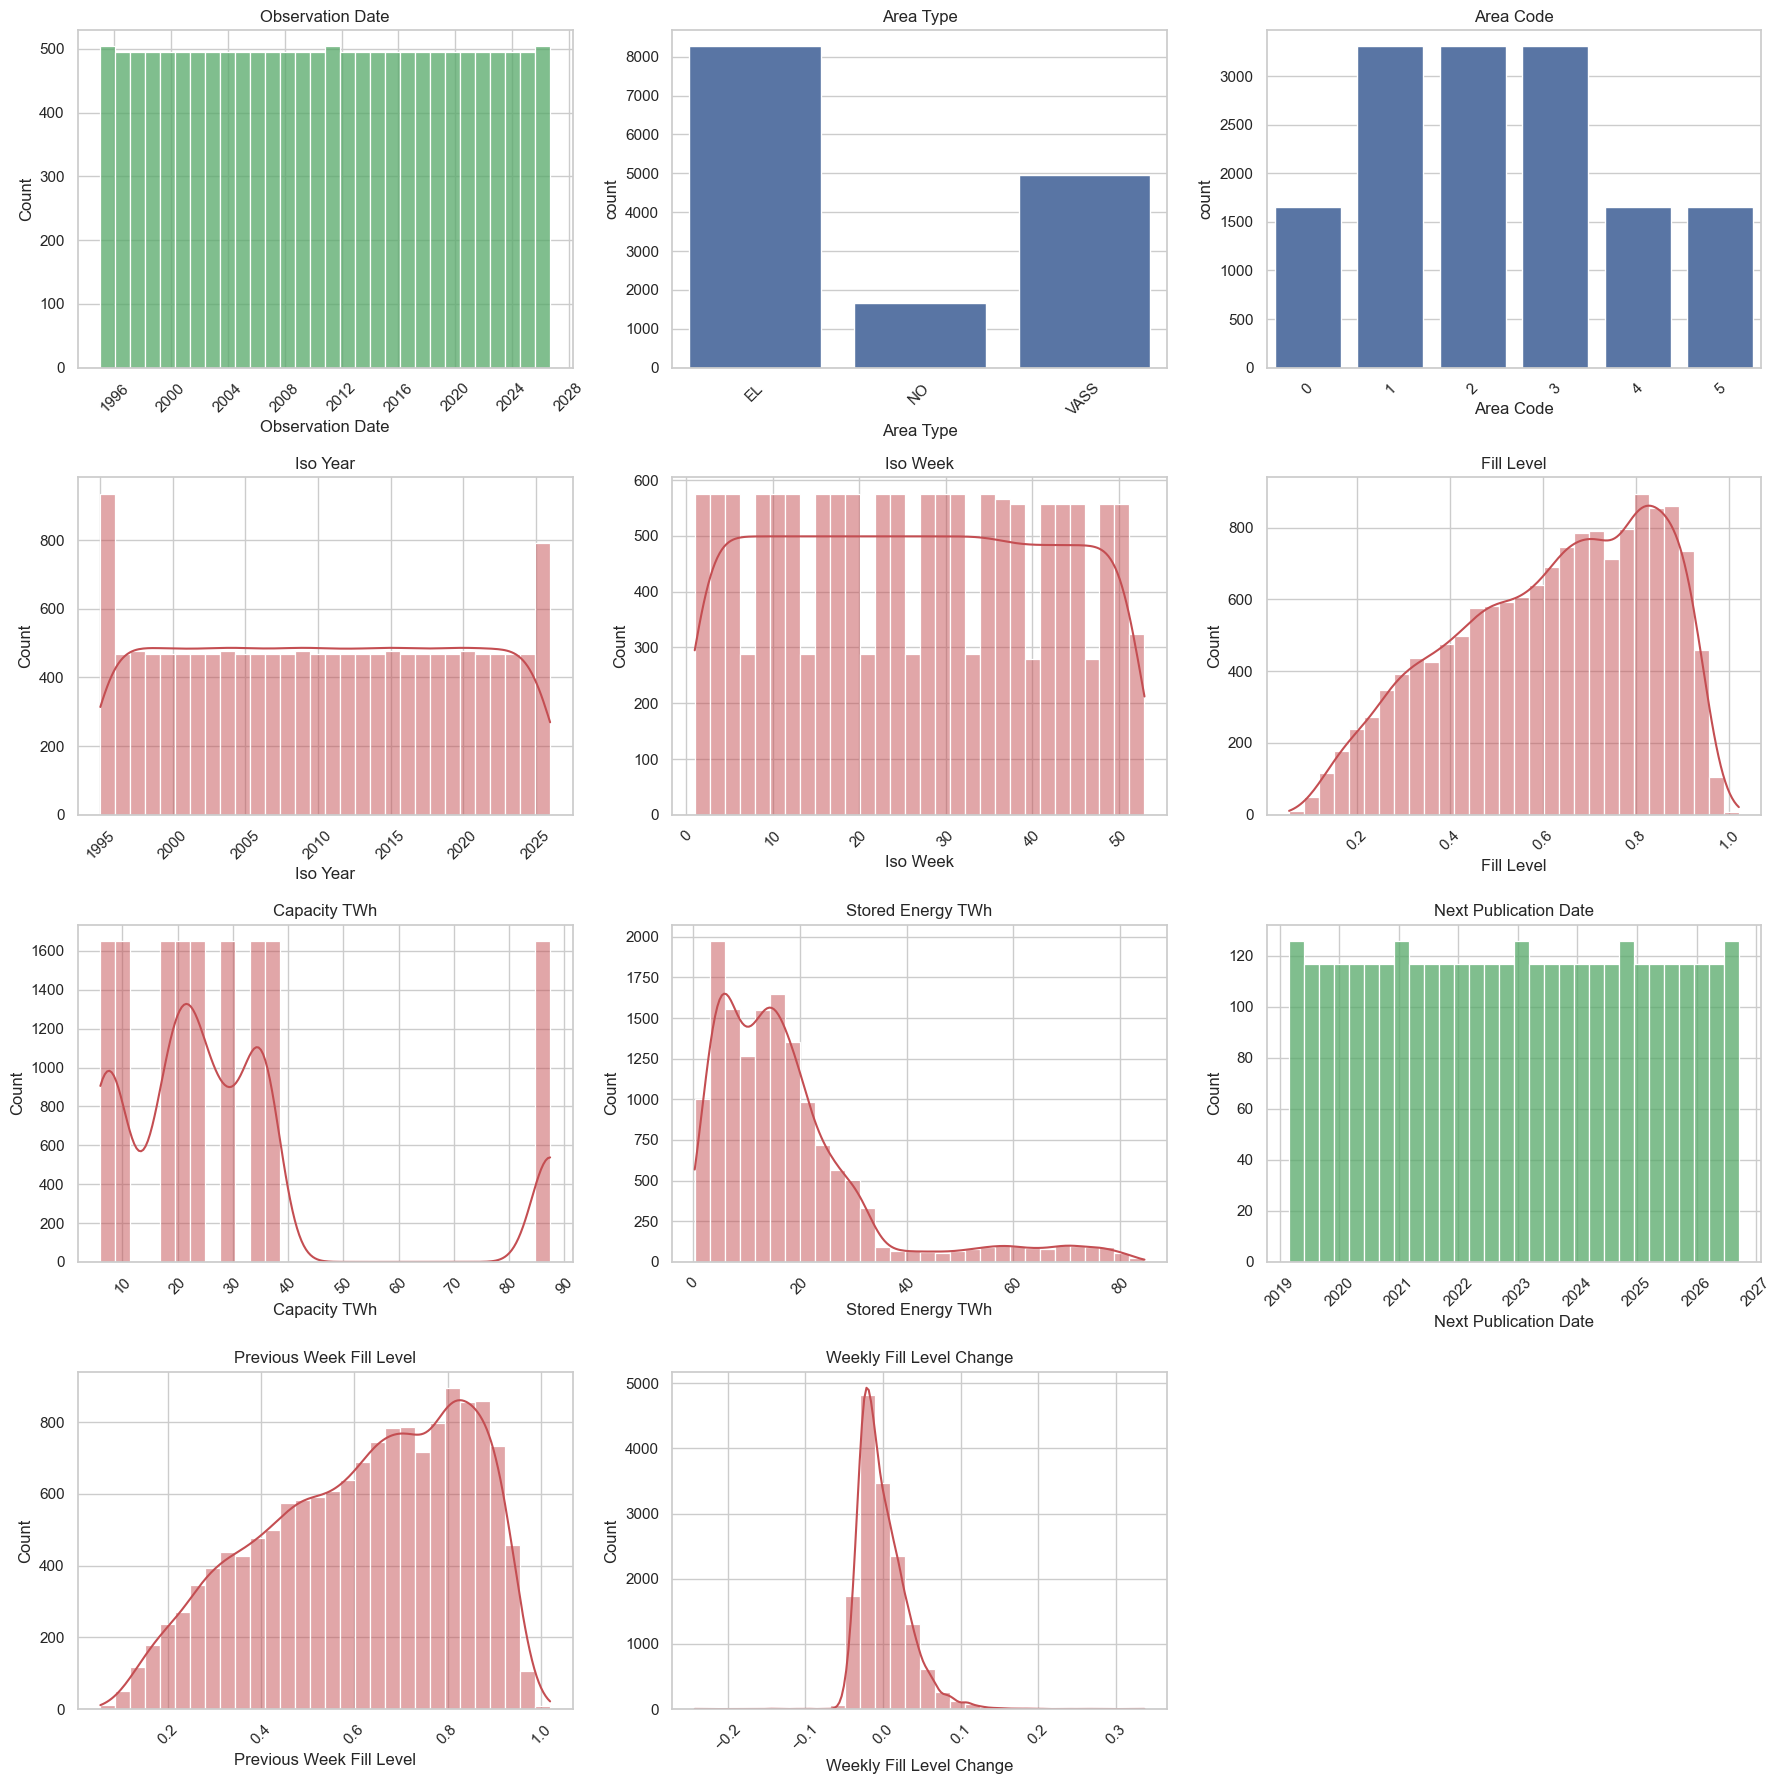

In [3]:
# One grid shows every field. Categories use counts; dates and numeric fields use distributions.
columns = df.columns.tolist()
n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = axes.flatten()

categorical_columns = ["Area Type", "Area Code"]
date_columns = ["Observation Date", "Next Publication Date"]

for ax, column in zip(axes, columns):
    plot_data = df[column].dropna()

    if column in categorical_columns:
        sns.countplot(data=df, x=column, ax=ax, color="#4C72B0")
    elif column in date_columns:
        sns.histplot(plot_data, bins=30, ax=ax, color="#55A868")
    else:
        sns.histplot(plot_data, bins=30, kde=True, ax=ax, color="#C44E52")

    ax.set_title(column)
    ax.tick_params(axis="x", rotation=45)

# Eleven fields leave one unused location in a three-column grid.
for ax in axes[len(columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Numeric columns on one comparable scale

The numeric variables use different units and ranges. Standardising each variable to z-scores makes their distributions comparable without pretending that TWh, weeks, and fill rates have the same original scale.

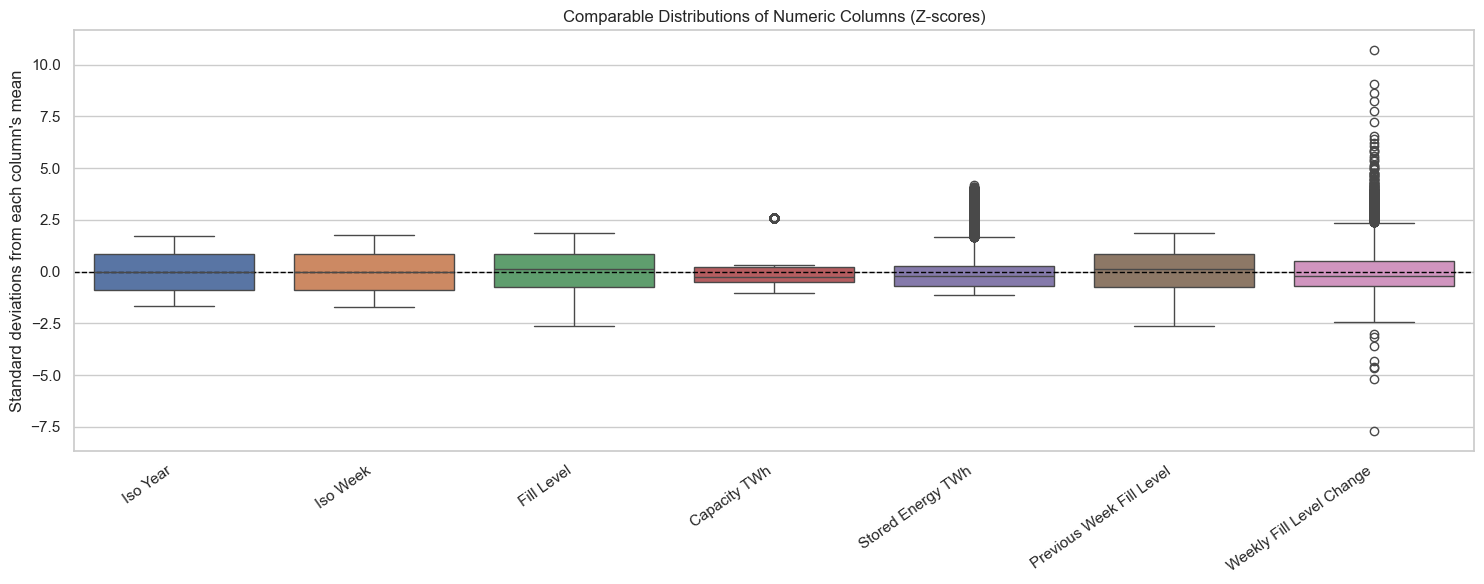

In [4]:
# Area codes are labels, so they are excluded. Dates stay as dates rather than arbitrary numbers.
numeric_columns = [
    "Iso Year",
    "Iso Week",
    "Fill Level",
    "Capacity TWh",
    "Stored Energy TWh",
    "Previous Week Fill Level",
    "Weekly Fill Level Change",
]

# A z-score of 0 is the column mean; +1 and -1 are one standard deviation away.
standardised = (df[numeric_columns] - df[numeric_columns].mean()) / df[numeric_columns].std()
comparison_data = standardised.melt(
    var_name="variable", value_name="z_score"
).dropna()

plt.figure(figsize=(15, 6))
sns.boxplot(data=comparison_data, x="variable", y="z_score", hue="variable", legend=False)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.title("Comparable Distributions of Numeric Columns (Z-scores)")
plt.xlabel("")
plt.ylabel("Standard deviations from each column's mean")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Compulsory work log and AI use

During this part of the project, I worked with a CSV file containing weekly Norwegian reservoir information. I used this Jupyter Notebook as the main place for loading the data, checking its structure, cleaning the date fields, and documenting my choices. The original headers were abbreviated Norwegian names, which made the dataset harder to read at a glance. I replaced them with clearer labels such as Observation Date, Area Type, Fill Level, and Stored Energy TWh. One important correction was adding the stored-energy column to the mapping. The first version of the mapping had shifted the fields and did not include it.

I then explored the data visually. The notebook contains a seaborn grid that gives each column its own plot. Categorical fields use count plots, while dates and numeric variables use distribution plots. This made it easier to spot the different kinds of data before deciding what to analyse further. I also added one combined numeric comparison. Since fill rates, TWh values, week numbers, and yearly values have very different scales, plotting their raw values together would not be useful. I standardised the numeric columns to z-scores and used box plots so their distributions can be compared without confusing their original units.

I used AI as a support tool for formatting the notebook, improving the column names, finding and fixing bugs, including the incorrect mapping, and researching the meaning of the original field names. AI also helped write and test the plotting code, build the Streamlit pages and cached data loader, and update pyproject.toml and uv.lock so the Python environment can be reproduced. I checked the suggested mapping against the actual CSV structure and verified the app locally. The final decisions about names, plots, and what to include remain my responsibility.

For the online counterpart, I read the same local CSV in a Streamlit app and pivoted its numeric filling-level measurements into nine weekly area series. The data page shows a first-month sparkline for each series alongside the source records. The plot page lets me compare one area or all nine and choose a range of months, starting with January 1995. Building the app showed me how Streamlit reruns a page when a control changes, why caching avoids repeated CSV processing, and why the long-form source must be reshaped for a clear time-series view. I checked all four pages locally before publishing.

- GitHub repository: [add public repository URL]
- Streamlit app: [add deployed app URL]